# Data Visualization 2: Relationships

To visualize a *relationship* we need at least two variables on the plot. Which plot to reach for depends on the **types** of the two variables:

- one numerical + one categorical,
- two categorical, or
- two numerical.

As before, each plot is chosen to answer a specific question, and our job is to read the answer off the chart.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# seaborn docs: https://seaborn.pydata.org/
import seaborn as sns

sns.set_theme()

# This notebook is self-contained: we load the penguins data again here.
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A numerical and a categorical variable

> Does body mass differ across penguin species?

A **box plot** summarizes a numerical variable for each category. Each box spans the middle half of the data (the interquartile range), the line inside marks the median, the whiskers reach the bulk of the rest, and isolated points flag possible outliers.

Text(0.5, 1.0, 'Body mass by species')

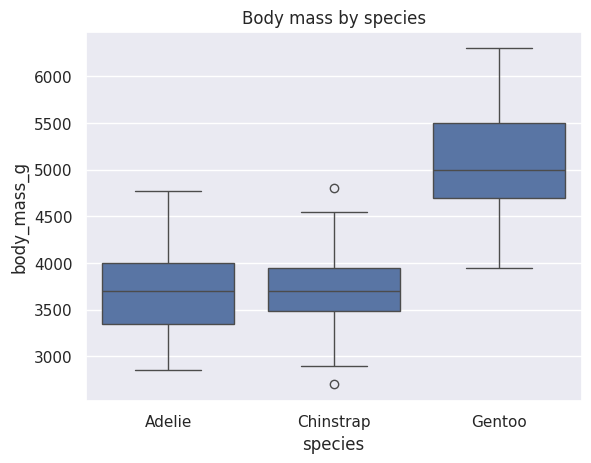

In [2]:
fig, ax = plt.subplots()

# boxplot: categorical x (species) vs numerical y (body mass), one box per species.
sns.boxplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass by species")

The boxes show that Gentoo penguins are clearly heavier than Adelie and Chinstrap, whose distributions overlap a lot.

We can ask the same question with overlapping **density curves**, one per species. Mapping `species` to `hue` draws and colors a curve for each group; `fill` with some transparency makes the overlaps readable.

Text(0.5, 1.0, 'Body mass distribution by species')

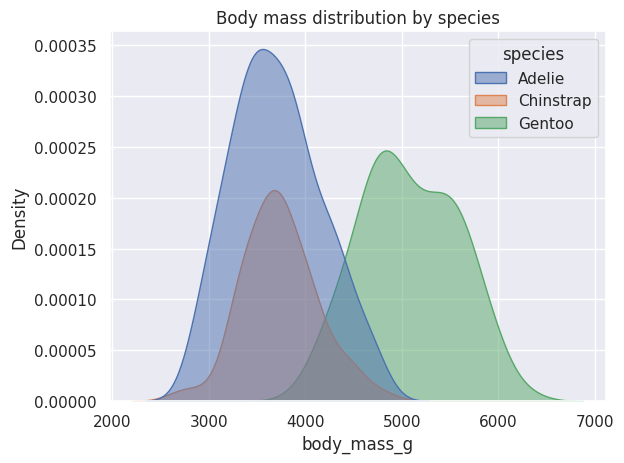

In [3]:
fig, ax = plt.subplots()

sns.kdeplot(
    data=penguins,
    x="body_mass_g",
    hue="species",   # one density curve per species, automatically colored
    fill=True,       # shade under each curve
    alpha=0.5,       # transparency (0 = invisible, 1 = solid) so curves don't hide each other
    ax=ax,
)

ax.set_title("Body mass distribution by species")

## Two categorical variables

> How are the species distributed across the islands?

With two categorical variables we count how often each combination occurs. `pd.crosstab` builds a table of counts that we can plot as a **stacked bar chart**.

In [4]:
# crosstab tallies how many penguins fall in each (island, species) combination.
island_species_counts = pd.crosstab(penguins["island"], penguins["species"])
island_species_counts

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


Text(0, 0.5, 'count')

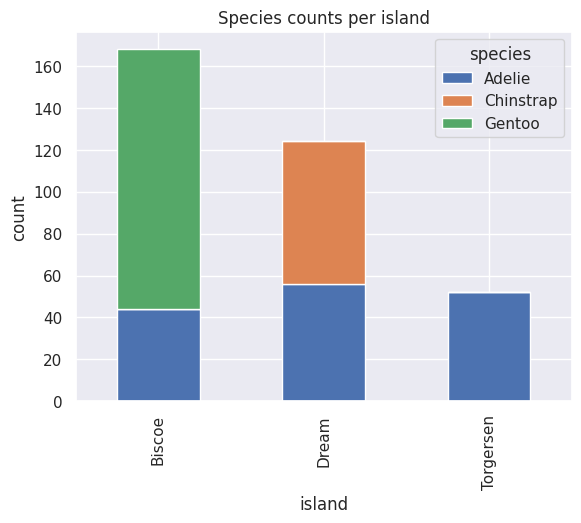

In [5]:
fig, ax = plt.subplots()

# A DataFrame can plot itself; stacked=True piles the species counts within each island.
island_species_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_title("Species counts per island")
ax.set_ylabel("count")

The raw counts are affected by the different number of penguins on each island. To compare the *composition* of each island, convert the counts to **proportions** with `normalize="index"` (each island's bars now sum to 1).

Text(0, 0.5, 'proportion')

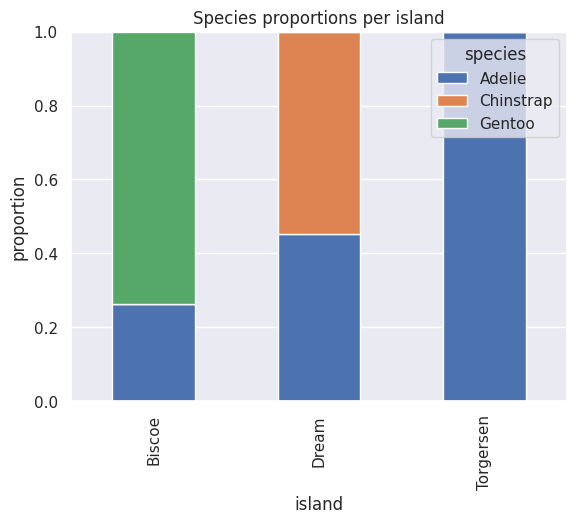

In [6]:
# normalize="index" turns each row of counts into proportions that sum to 1.
island_species_proportions = pd.crosstab(
    penguins["island"],
    penguins["species"],
    normalize="index",
)

fig, ax = plt.subplots()

island_species_proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_title("Species proportions per island")
ax.set_ylabel("proportion")

Now the story is clear: Gentoo penguins live only on Biscoe, Chinstrap only on Dream, and Adelie are found on all three islands (and are the only species on Torgersen).

## Two numerical variables

> What does the relationship between flipper length and body mass look like?

A **scatterplot** is the workhorse for two numerical variables, and `regplot` adds a line of best fit when we want to summarize the trend.

Text(0.5, 1.0, 'Body mass vs. flipper length')

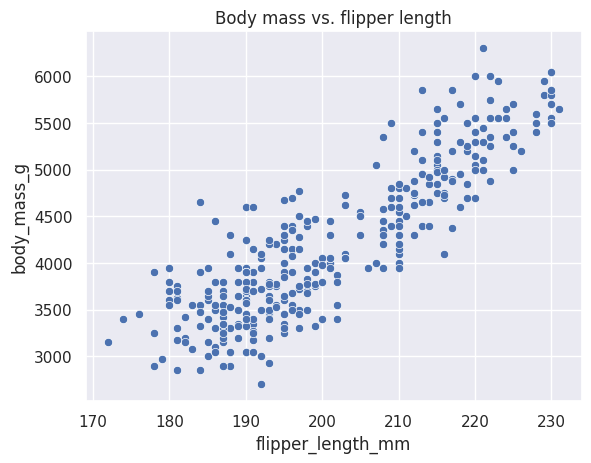

In [7]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass vs. flipper length")

Text(0.5, 1.0, 'Body mass vs. flipper length with a line of best fit')

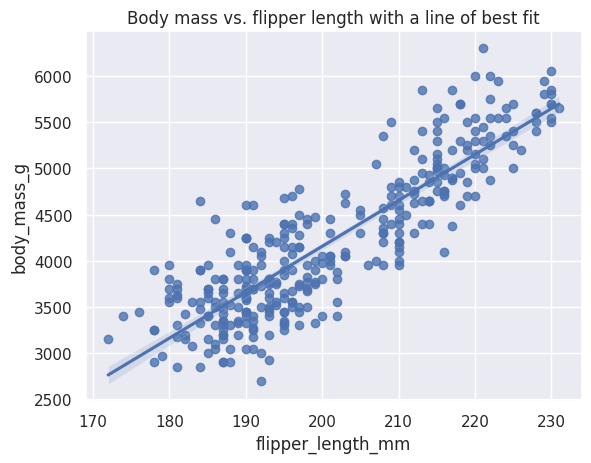

In [8]:
fig, ax = plt.subplots()

# regplot overlays a fitted straight line to summarize the trend.
sns.regplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass vs. flipper length with a line of best fit")

## Three or more variables (optional)

We can squeeze in a third variable by mapping it to `hue`, `style`, or `size` — but adding too many at once makes a plot hard to read.

A cleaner option for a categorical third variable is **faceting**: splitting the data into small side-by-side subplots. seaborn's figure-level `relplot` does this with `col=`.

Text(0.5, 1.02, 'Body mass vs. flipper length, faceted by island')

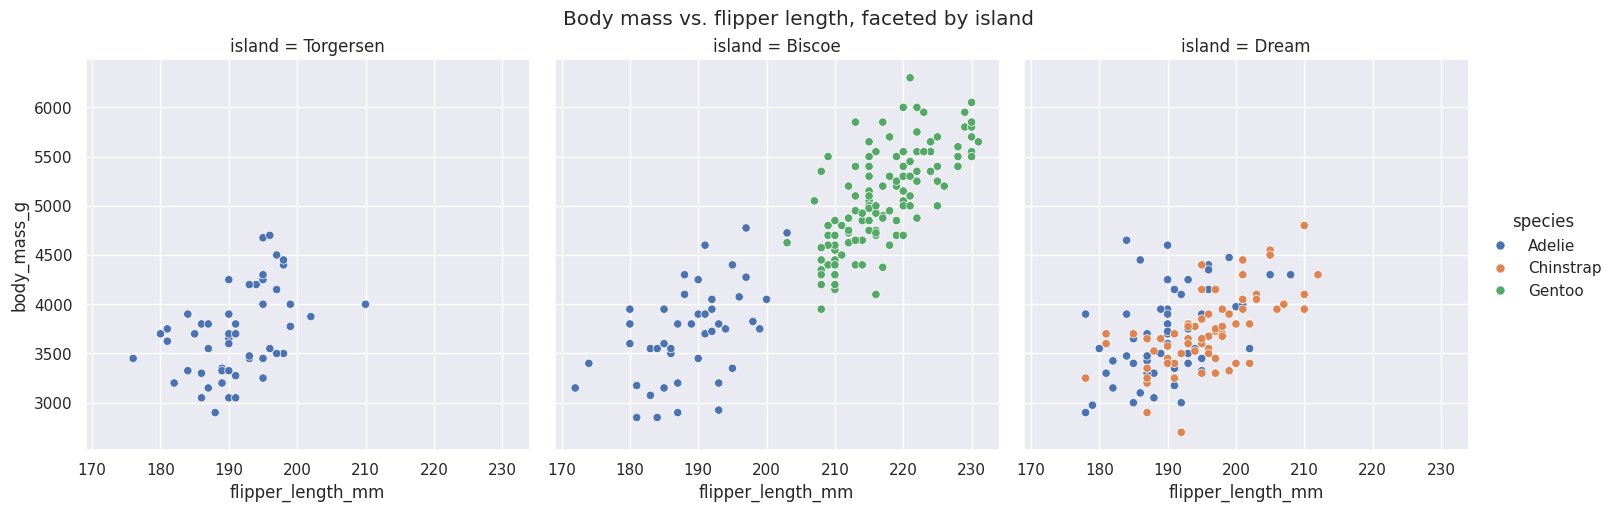

In [9]:
# relplot is figure-level: it manages its own grid of subplots, so we don't pass ax.
grid = sns.relplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # color points by species
    col="island",    # one subplot (facet) per island
    kind="scatter",
)

grid.figure.suptitle("Body mass vs. flipper length, faceted by island", y=1.02)

## Summary

- **Numerical vs. categorical**: a **box plot** (`sns.boxplot`) or overlapping **density curves** (`sns.kdeplot` with `hue`) compare a number across groups.
- **Two categorical**: a **stacked bar chart** of `pd.crosstab` counts shows raw frequencies; switching to **proportions** (`normalize="index"`) compares composition fairly.
- **Two numerical**: a **scatterplot** (`sns.scatterplot`), optionally with a fitted line (`sns.regplot`).
- For a third variable, use `hue`/`style`/`size` sparingly, or **facet** with `sns.relplot(col=...)`.